In [19]:
import os
from os.path import join
import gzip
import shutil
from nilearn.image import load_img, resample_img
from nilearn import image
import numpy as np
from statsmodels.stats.multitest import fdrcorrection
import pandas as pd
import nibabel as nib
import glob
from scipy.stats import ttest_1samp, false_discovery_control, ttest_rel
from IPython.display import display
from statsmodels.stats.multitest import fdrcorrection
from nilearn.image import math_img, new_img_like
from nilearn.regions import connected_regions
from nilearn.image import index_img
from scipy.ndimage import center_of_mass
from kneed import KneeLocator

In [95]:
subjects = [f"{i:02d}" for i in range(1,23) if i not in [9, 16]]
project_dir = "/Users/danieljanini/Documents/project_miniblock" 

In [101]:
localizer_accuracies = {}

# Loop over subjects and runs
for sub in subjects:  
    
    for run in range(1,4):  
        
        # Get the presentation file's path
        pattern = join(project_dir, f'Behavior/LocData/P0{sub}_CategoryLocalizer_Run{run}_*.csv')
        matches = glob.glob(pattern)

        if matches == []:
            print(f"Run {run} not found for subject {sub}. Skipping.")
            continue

        # Read the file
        df = pd.read_csv(matches[0])

        repeats = []
        image = ['start']
        
        for i in range(len(df)):
            if image == df["imFile"][i]:
                repeats.append(1)
            else: 
                repeats.append(0)
            if df["imFile"][i] != r"Stimuli\Blank.png":
                image = df["imFile"][i]


        df["repeats"] = repeats
        condition = (df['repeats'] == 1) 
        df_filtered = df[condition]

        df_filtered = df_filtered.copy()
        # Create a new column "responseWindow" with the given formula
        df_filtered[ "responseWindow"] = (df_filtered["eventStartTime"].fillna(0) + 5)

        # Calculate accuracy based on participant response time
        correct_responses = (df_filtered["eventStartTime"] + df_filtered["participantResponse.rt"] <= df_filtered["responseWindow"])
        accuracy = 100 * correct_responses.sum() / len(df_filtered)
        localizer_accuracies[f"sub{sub}_run{run}"] = {
                "accuracy": accuracy
            }

Run 3 not found for subject 01. Skipping.
Run 3 not found for subject 02. Skipping.
Run 3 not found for subject 05. Skipping.
Run 3 not found for subject 11. Skipping.
Run 3 not found for subject 12. Skipping.


In [102]:
localizer_accuracies

{'sub01_run1': {'accuracy': 100.0},
 'sub01_run2': {'accuracy': 100.0},
 'sub02_run1': {'accuracy': 95.83333333333333},
 'sub02_run2': {'accuracy': 100.0},
 'sub03_run1': {'accuracy': 100.0},
 'sub03_run2': {'accuracy': 100.0},
 'sub03_run3': {'accuracy': 100.0},
 'sub04_run1': {'accuracy': 91.66666666666667},
 'sub04_run2': {'accuracy': 91.66666666666667},
 'sub04_run3': {'accuracy': 95.83333333333333},
 'sub05_run1': {'accuracy': 87.5},
 'sub05_run2': {'accuracy': 83.33333333333333},
 'sub06_run1': {'accuracy': 100.0},
 'sub06_run2': {'accuracy': 95.83333333333333},
 'sub06_run3': {'accuracy': 87.5},
 'sub07_run1': {'accuracy': 91.66666666666667},
 'sub07_run2': {'accuracy': 95.83333333333333},
 'sub07_run3': {'accuracy': 95.83333333333333},
 'sub08_run1': {'accuracy': 75.0},
 'sub08_run2': {'accuracy': 100.0},
 'sub08_run3': {'accuracy': 95.83333333333333},
 'sub10_run1': {'accuracy': 100.0},
 'sub10_run2': {'accuracy': 87.5},
 'sub10_run3': {'accuracy': 100.0},
 'sub11_run1': {'acc

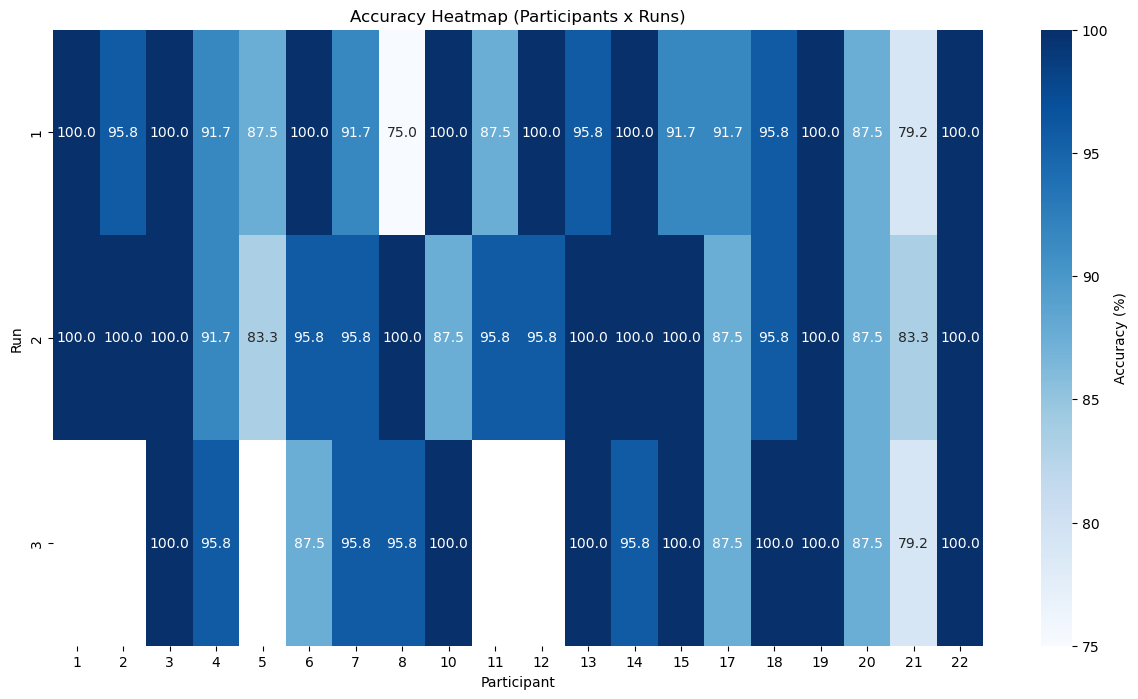

In [105]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert the accuracies dict into a DataFrame
df_acc = pd.DataFrame.from_dict(localizer_accuracies, orient='index').reset_index()
df_acc[['sub', 'run']] = df_acc['index'].str.extract(r'sub(\d+)_run(\d+)')
df_acc['sub'] = df_acc['sub'].astype(int)
df_acc['run'] = df_acc['run'].astype(int)

# Pivot to wide format (runs as rows, subs as columns)
heatmap_data = df_acc.pivot(index='run', columns='sub', values='accuracy')

# Plot heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="Blues", cbar_kws={'label': 'Accuracy (%)'})
plt.xlabel('Participant')
plt.ylabel('Run')
plt.title('Accuracy Heatmap (Participants x Runs)')
plt.show()


In [ ]:
def RSA_between(project_dir, spearman=True):
    """
    Function that calculates RSA between particpants for every ROI. 
    Set spearman to False to use Pearson's r instead. 
    Returns nothing but saves a dataframe of results to the RSA/ROI_between folder.
    """

    # Set up directories 
    outdir = join(project_dir, 'miniblock/Outputs/')
    datadir = join(project_dir, 'miniblock/')

    # Set up pairs dictionary 
    # Since participants 9 and 16 had to be excluded, 21 and 22 are taking their place 
    pairs_dict = {"pair_1" : ["01", "02"], 
                "pair_2" : ["03", "04"], 
                "pair_3" : ["05", "06"], 
                "pair_4" : ["07", "08"], 
                "pair_5" : ["11", "12"], 
                "pair_6" : ["13", "14"], 
                "pair_7" : ["17", "18"],
                "pair 8" : ["19", "20"],
                "pair 9" : ["10", "21"],
                "pair 10": ["15", "22"]}
    smooths = ['sm_2_vox'] # only smoothed data
    presdir = join(project_dir, 'Behavior', 'designmats')
    runtypes = ['sus', 'miniblock', 'er']
    ROIs = ["EBA","FFA", "PPA", "EVC" ]

    correlation_results = [] # store results here
    for ROI in ROIs: 
        for pair_name, subjects in pairs_dict.items():
            #print(f"Now working on {pair_name} in ROI: {ROI}")
            for runtype in runtypes: 
                    for smoothing in smooths:
                        upper_triangles_flattened = [] # store flattened upper triangles 
                        # loop over both subjects
                        for sub in subjects: 
                            # Load GLMsingle Outputs
                            results_glmsingle = dict()
                            results_glmsingle['typed'] = np.load(join(outdir,"GLMSingle_Outputs",f'{smoothing}_sub-{sub}_{runtype}_TYPED_FITHRF_GLMDENOISE_RR.npy'), allow_pickle=True).item()
                            betas = results_glmsingle['typed']['betasmd']

                            # load the participant-specific ROI mask 
                            brain_mask_path = join(datadir, 'derivatives', f'sub-{sub}', 'anat', f'{ROI}_mask_sm_2_vox.nii')
                            brain_mask = image.load_img(brain_mask_path)
                            mask = brain_mask.get_fdata()   
                            # Mask betas 
                            masked_betas = betas[mask.astype(bool)]
                            # Get design matrix from GLMsingle
                            pattern = presdir + f'/P0{sub}_ConditionRich_Run*_{runtype}.csv'
                            matches = glob.glob(pattern)
                            matches.sort()
                            
                            design = []
                            for i in range(len(matches)):
                                designMat = pd.read_csv(matches[i], header=None)
                                design.append(designMat)

                            all_design = np.vstack((design[0], design[1], design[2]))
                            condition_mask = all_design.sum(axis=1) > 0
                            # a vector assigning conditions to trials
                            condition_vector = np.argmax(all_design[condition_mask], axis=1)
                            # Get the beta values into a vector 
                            n_conditions = 40
                            max_reps = 6

                            # create a matrix of shape trials by condition containing the indices 
                            repindices = np.full((max_reps, n_conditions), np.nan)
                            for p in range(n_conditions):  
                                inds = np.where(condition_vector == p)[0]  
                                repindices[:len(inds), p] = inds  
                            
                            # prepare empty array to store betas per repitition per condition
                            X, T = masked_betas.shape
                            n_reps, n_conds = repindices.shape
                            betas_per_condition = np.full((X, n_reps, n_conds), np.nan)

                            # loop over conditions and fill the betas_per_condition matrix
                            for cond in range(n_conds):
                                trial_indices = repindices[:, cond]
                                for rep, trial_idx in enumerate(trial_indices):
                                    if not np.isnan(trial_idx):
                                        trial_idx = int(trial_idx)
                                        betas_per_condition[:, rep, cond] = masked_betas[:, trial_idx]

                            # result: number of voxels by repetitions by conditions
                            # calculate mean over all trials
                            all_betas_means = betas_per_condition.mean(axis=-2)
                            all_betas = all_betas_means.T #transpose 
                            upper_triangle = pdist(all_betas, metric='correlation') # get similarity matrix and extract upper triangle
                            upper_triangles_flattened.append(upper_triangle)
                        # Calculate correlation between the two subjects
                        if spearman: 
                            cor, p_value = spearmanr(upper_triangles_flattened[0], upper_triangles_flattened[1])
                        else: 
                            cor, p_value = pearsonr(upper_triangles_flattened[0], upper_triangles_flattened[1])
                        # append to results 
                        correlation_results.append({
                                    "pair": pair_name,
                                    "ROI": ROI,
                                    "runtype": runtype,
                                    "smoothing": smoothing,
                                    "correlation": cor})
    # store as csv file after doing all pairs
    if spearman:                        
        os.makedirs(join(outdir,"RSA/ROI_between"),exist_ok=True)
        pd.DataFrame(correlation_results).to_csv(join(outdir,"RSA/ROI_between","rsa_results_spearman_between.csv"), index=False)
    else: 
        pd.DataFrame(correlation_results).to_csv(join(outdir,"RSA/ROI_between","rsa_results_pearson_between.csv"), index=False)


In [ ]:
def group_results_noise_ceiling(dataframe):

    """
    Does repeated measures ANOVAs for every ROI and smoothing option the dataframe contains over the designs. 
    Afterwards, FDR-corrected post-hoc paired t-tests are calculated.
    A binary dataframe of the ROIs and smoothing options as rows and the pairwise comparisons between designs as colummns
    is returned:
    0 indicates not significant, 
    1 indicates significance
    """
    # specify smoothing and ROIs
    ROIs = ["visually_responsive_voxels", "FFA", "PPA", "EBA", "EVC"]
    smooths = ["sm_2_vox", "unsmoothed"]

    significant_df = []

    for ROI in ROIs:
        for smoothing in smooths:
            # filter for an ROI
            df = dataframe[dataframe["ROI"] == ROI]
            # filter for a smoothing option and calculate the mean noise ceiling value within that ROI
            df = (
                df[df["smoothing"] == smoothing]
                .groupby(["subject", "runtype"], as_index=False)["median_nc"]
                .mean()
            )

            # Run repeated-measures ANOVA
            aov = AnovaRM(data=df, depvar='median_nc', subject='subject', within=["runtype"])
            aov_res = aov.fit()

            # Pairwise comparisons
            runtype_conditions = df['runtype'].unique()
            comparisons = list(combinations(runtype_conditions, 2))

            pvals = []
            results = []
            # turn this into a wide dataframe
            df_wide = df.pivot(index='subject', columns='runtype', values='median_nc')

            # compare all designs against each other (pairwise)
            for cond1, cond2 in comparisons:
                t_stat, p_val = ttest_rel(df_wide[cond1], df_wide[cond2])
                pvals.append(p_val)
                results.append((cond1, cond2, t_stat, p_val))

            # correct for multiple comparisons 
            _, pvals_corrected, _, _ = smm.multipletests(pvals, method='fdr_bh')

            # Build row dictionary 
            row = {"ROI": ROI, "smoothing": smoothing}

            for i, (cond1, cond2, t_stat, p_val) in enumerate(results):
                label = f"{cond1}_vs_{cond2}"
                row[f"{label}_t"] = t_stat
                row[f"{label}_p_uncorrected"] = p_val
                row[f"{label}_p_corrected"] = pvals_corrected[i]
            # store all results to be printed out
            significant_df.append(row)

    # Convert to DataFrame
    significant_df = pd.DataFrame(significant_df)
    significant_df = significant_df[["ROI", "smoothing", "er_vs_miniblock_p_corrected", "er_vs_sus_p_corrected", "miniblock_vs_sus_p_corrected"]]
    # List of p-value columns
    pval_cols = ["er_vs_miniblock_p_corrected", "er_vs_sus_p_corrected", "miniblock_vs_sus_p_corrected"]

    # Create a copy to avoid modifying the original
    binary_df = significant_df.copy()

    # Replace p-value columns with 1 if p < 0.05 else 0 to indicate significance
    binary_df[pval_cols] = (binary_df[pval_cols] < 0.05).astype(int)

    return binary_df


In [5]:
subjects = [f"{i:02d}" for i in range(1,23) if i not in [9, 16]]
project_dir = "/Users/danieljanini/Documents/project_miniblock" 
ROIs = ["FFA", "PPA", "EVC", "EBA"]

In [ ]:
def PCA_voxels(mean_betas):
    """
    PCA function using SVD to extract number of principle components of matrix shaped 
    number of conditions by number of voxels. 
    Maximum number of components is 39. 
    """
    # Standardize (assuming data is shape conditions (40) by voxels (whatever size the ROI is))
    X_standard = (mean_betas - np.mean(mean_betas, axis=0)) / np.std(mean_betas, axis = 0)
    n_samples = X_standard.shape[0]
    n_features = X_standard.shape[1]

    # Compute eigenvalues
    U, L, V = np.linalg.svd(X_standard, full_matrices=False)

    # Sort eigenvalues 
    eigvals = L
    idx = eigvals.argsort()[::-1]
    eigvals = eigvals[idx]
    eigvecs = V[:,idx]

    # Return % of explained variance for each PC
    explained_variance = (L**2) / (n_samples - 1)
    explained_variance_ratio = explained_variance / np.sum(explained_variance)

    return eigvecs, explained_variance_ratio

# set up directories
outdir = join(project_dir, "miniblock/Outputs")
datadir = join(project_dir, "miniblock")
smooths = ['sm_2_vox']
presdir = join(project_dir, 'Behavior', 'designmats')
runtypes = ['sus', 'miniblock', 'er']
# store results
# track explained variance by each component in the train data
explained_variance_train = np.zeros(shape=(20,3,4,3,40))
# track eigenvectors
all_eigenvectors = np.zeros(shape=(20,3,4,3,40,40))
# track explained variance in the test data 
explained_variance_test = np.zeros((20,3,4,3))
# track first 39 components (test data)
first_39_components = np.zeros(shape=(20,3,4,6,39))


for sub in range(len(subjects)):
    for runtype in range(len(runtypes)): 
            for smoothing in range(len(smooths)):
                for ROI in range(len(ROIs)):
                    # load GLMsingle outputs
                    results_glmsingle = dict()
                    results_glmsingle['typed'] = np.load(join(outdir,"GLMSingle_Outputs",f'{smooths[smoothing]}_sub-{subjects[sub]}_{runtypes[runtype]}_TYPED_FITHRF_GLMDENOISE_RR.npy'), allow_pickle=True).item()
                    betas = results_glmsingle['typed']['betasmd']

                    brain_mask_path = join(datadir, 'derivatives', f'sub-{subjects[sub]}', 'anat', f'{ROIs[ROI]}_mask_sm_2_vox.nii')
                    brain_mask = image.load_img(brain_mask_path)
                    mask = brain_mask.get_fdata()   
                    # apply mask
                    masked_betas = betas[mask.astype(bool)]

                    # get design matrix from GLMsingle
                    pattern = presdir + f'/P0{subjects[sub]}_ConditionRich_Run*_{runtypes[runtype]}.csv'
                    matches = glob.glob(pattern)
                    matches.sort()
                    
                    design = []
                    for i in range(len(matches)):
                        designMat = pd.read_csv(matches[i], header=None)
                        design.append(designMat)

                    all_design = np.vstack((design[0], design[1], design[2]))
                    condition_mask = all_design.sum(axis=1) > 0
                    # a vector assigning condtions to trials
                    condition_vector = np.argmax(all_design[condition_mask], axis=1)
                    # Get the beta values into a vector 
                    n_conditions = 40
                    max_reps = 6

                    # create a matrix of shape trials by condition containing the indices 
                    repindices = np.full((max_reps, n_conditions), np.nan)
                    for p in range(n_conditions):  
                        inds = np.where(condition_vector == p)[0]  
                        repindices[:len(inds), p] = inds  
                    
                    # prepare empty array to store betas per repitition per condition
                    X, T = masked_betas.shape
                    n_reps, n_conds = repindices.shape
                    betas_per_condition = np.full((X, n_reps, n_conds), np.nan)

                    # loop over conditions and fill the betas_per_condition matrix
                    for cond in range(n_conds):
                        trial_indices = repindices[:, cond]
                        for rep, trial_idx in enumerate(trial_indices):
                            if not np.isnan(trial_idx):
                                trial_idx = int(trial_idx)
                                betas_per_condition[:, rep, cond] = masked_betas[:, trial_idx]


                    # Apply cross-validated PCA
                    for i in range(3):
                        if i == 0:
                            # Get the indices for the train data
                            train_idx = np.array((2,3,4,5))
                            test_idx = np.array((0,1))
                        elif i == 1: 
                            # Get the indices for the train data
                            train_idx = np.array((0,1,4,5))
                            test_idx = np.array((2,3))
                        elif i == 2:
                            # Get the indices for the train data
                            train_idx = np.array((0,1,2,3))
                            test_idx = np.array((4,5))
                        
                        # filter for train data
                        beta_filtered = betas_per_condition[:,train_idx,:]
                        beta_filtered_mean = beta_filtered.mean(axis=0)
                        beta_filtered_sd = beta_filtered.std(axis=0)
                        # filter for test data
                        beta_filtered_test = betas_per_condition[:,test_idx,:]
                        beta_filtered_test_centered = (beta_filtered_test - beta_filtered_mean) / beta_filtered_sd
                        # calculate mean over the train betas
                        beta_filtered_mean = beta_filtered.mean(axis=1)
                        # Apply PCA, extract eigenvectors and explained variance
                        eigvecs, explained_variance_ratio = PCA_voxels(beta_filtered_mean.T)

                        # project hold-out betas onto the fitted PCs
                        # center data first, then project
                        beta_filtered_test_centered = beta_filtered_test_centered.mean(axis=1)
                        beta_test_projected = beta_filtered_test_centered @ eigvecs[:10].T
                        test_reconstructed = beta_test_projected @ eigvecs[:10]
                        kneedle = KneeLocator(range(1, 40), mean_R2, curve='concave', direction='increasing')
                        knee_k = kneedle.knee

                        # store eigenvectors and explained variance in the train set
                        explained_variance_train[sub, runtype, ROI, :] = explained_variance_ratio
                        all_eigenvectors[sub, runtype, ROI, :, :] = eigvecs

                        # Comparison to original test data
                        num = np.sum((beta_filtered_test_centered - test_reconstructed) ** 2)  # residual error
                        den = np.sum(beta_filtered_test_centered ** 2)                         # total variance
                        explained_var_k = 1 - num / den
                        explained_variance_test[sub, runtype, ROI,i] = explained_var_k


In [17]:
for i in range(3):
    for j in range(4):
        print(ROIs[j], runtypes[i],explained_variance_test.mean(axis=0)[i,j,:].mean())

FFA sus 0.1134697421997829
PPA sus 0.08661030981474631
EVC sus 0.0181232493917519
EBA sus 0.034352230374155295
FFA miniblock 0.14069093252545523
PPA miniblock 0.0928920576161187
EVC miniblock 0.01946031028065738
EBA miniblock 0.04450847456802782
FFA er 0.0741086207412245
PPA er 0.06145808284904732
EVC er 0.009500526413142666
EBA er 0.02038391308045154


In [15]:
np.array((2,3,4,5))

array([2, 3, 4, 5])

In [18]:
pip install kneed

Note: you may need to restart the kernel to use updated packages.


In [ ]:
####

### Try new approach

In [129]:
def cv_pca_curves(betas_per_run):
    """
    betas_per_run: (voxels, runs=3, conds=40)
    returns: folds x Kmax array of R² curves
    """
    V, n_runs, C = betas_per_run.shape
    Kmax = C - 1
    curves = np.zeros((n_runs, Kmax))

    for test_run in range(n_runs):
        train_runs = [r for r in range(n_runs) if r != test_run]
        X_train = betas_per_run[:,train_runs,:].mean(axis=1)
        X_test  = betas_per_run[:,test_run,:]

        # Standardize
        mu = X_train.mean(axis=0)
        sd = X_train.std(axis=0, ddof=1)
        sd[sd==0] = 1.0
        Xtr = (X_train - mu) / sd
        Xte = (X_test  - mu) / sd
        Xtr = Xtr.T
        Xte = Xte.T

        # PCA
        U, S, Vt = np.linalg.svd(Xtr, full_matrices=False)
        Vvox = Vt.T

        # R² curve
        for k in range(1, Kmax+1):
            Uk = Vvox[:, :k]
            scores_te = Xte @ Uk
            Xte_hat = scores_te @ Uk.T
            num = np.sum((Xte - Xte_hat)**2)
            den = np.sum(Xte**2)
            curves[test_run, k-1] = 1 - num/den

    return curves

# set up directories
outdir = join(project_dir, "miniblock/Outputs")
datadir = join(project_dir, "miniblock")
smooths = ['sm_2_vox']
presdir = join(project_dir, 'Behavior', 'designmats')
runtypes = ['sus', 'miniblock', 'er']
# store results
# track explained variance by each component in the train data
number_of_components = np.zeros(shape=(20,3,4))
all_R2 = np.zeros(shape=(20,3,4,39))

for sub in range(len(subjects)):
    for runtype in range(len(runtypes)): 
            for smoothing in range(len(smooths)):
                for ROI in range(len(ROIs)):
                    # load GLMsingle outputs
                    results_glmsingle = dict()
                    results_glmsingle['typed'] = np.load(join(outdir,"GLMSingle_Outputs",f'{smooths[smoothing]}_sub-{subjects[sub]}_{runtypes[runtype]}_TYPED_FITHRF_GLMDENOISE_RR.npy'), allow_pickle=True).item()
                    betas = results_glmsingle['typed']['betasmd']

                    brain_mask_path = join(datadir, 'derivatives', f'sub-{subjects[sub]}', 'anat', f'{ROIs[ROI]}_mask_sm_2_vox.nii')
                    brain_mask = image.load_img(brain_mask_path)
                    mask = brain_mask.get_fdata()   
                    # apply mask
                    masked_betas = betas[mask.astype(bool)]

                    # get design matrix from GLMsingle
                    pattern = presdir + f'/P0{subjects[sub]}_ConditionRich_Run*_{runtypes[runtype]}.csv'
                    matches = glob.glob(pattern)
                    matches.sort()
                    
                    design = []
                    for i in range(len(matches)):
                        designMat = pd.read_csv(matches[i], header=None)
                        design.append(designMat)

                    all_design = np.vstack((design[0], design[1], design[2]))
                    condition_mask = all_design.sum(axis=1) > 0
                    # a vector assigning condtions to trials
                    condition_vector = np.argmax(all_design[condition_mask], axis=1)
                    # Get the beta values into a vector 
                    n_conditions = 40
                    max_reps = 6

                    # create a matrix of shape trials by condition containing the indices 
                    repindices = np.full((max_reps, n_conditions), np.nan)
                    for p in range(n_conditions):  
                        inds = np.where(condition_vector == p)[0]  
                        repindices[:len(inds), p] = inds  
                    
                    # prepare empty array to store betas per repitition per condition
                    X, T = masked_betas.shape
                    n_reps, n_conds = repindices.shape
                    betas_per_condition = np.full((X, n_reps, n_conds), np.nan)

                    # loop over conditions and fill the betas_per_condition matrix
                    for cond in range(n_conds):
                        trial_indices = repindices[:, cond]
                        for rep, trial_idx in enumerate(trial_indices):
                            if not np.isnan(trial_idx):
                                trial_idx = int(trial_idx)
                                betas_per_condition[:, rep, cond] = masked_betas[:, trial_idx]
                    
                    betas_per_run = np.zeros(shape=(betas_per_condition.shape[0],3,betas_per_condition.shape[2]))
                    betas_per_run[:,0,:] = betas_per_condition[:,:2,:].mean(axis=1)
                    betas_per_run[:,1,:] = betas_per_condition[:,2:4,:].mean(axis=1)
                    betas_per_run[:,2,:] = betas_per_condition[:,4:,:].mean(axis=1)
                    
                    subject_curves = cv_pca_curves(betas_per_run)
                    mean_R2 = subject_curves.mean(axis=0)
                    all_R2[sub,runtype,ROI,:] = mean_R2

                    kneedle = KneeLocator(range(0, 39), mean_R2, curve='concave', direction='increasing')
                    knee_k = kneedle.knee
                    number_of_components[sub,runtype,ROI] = knee_k




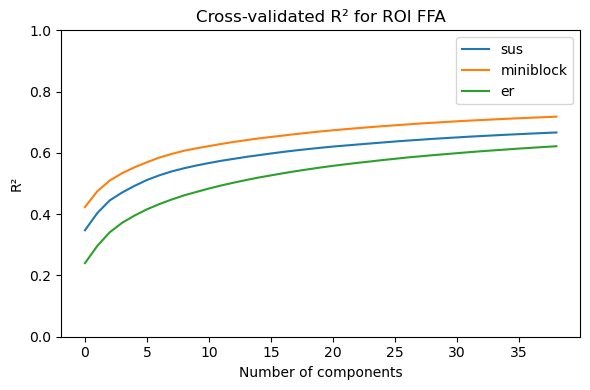

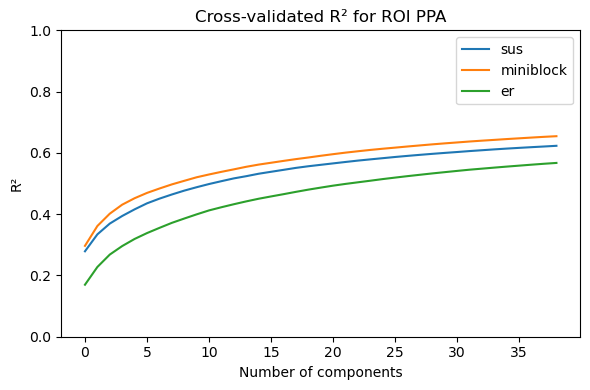

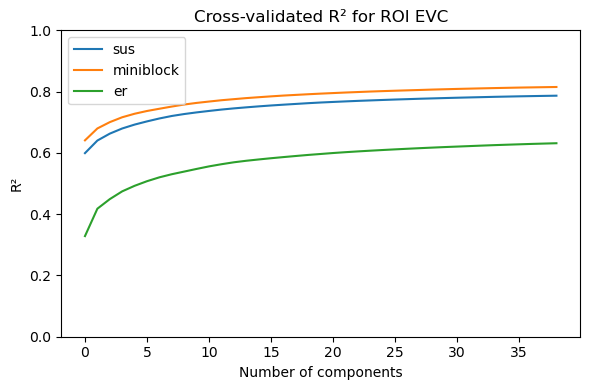

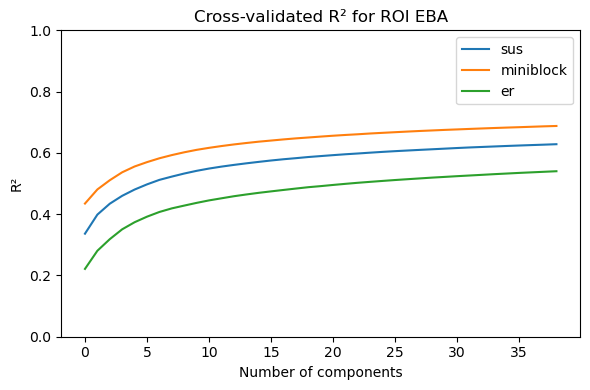

In [141]:
import matplotlib.pyplot as plt

# average across subjects
R2_over_all_subs = all_R2.mean(axis=0)  # shape: (runtypes=3, ROIs=4, Kmax=39)

for ROI in range(4):
    plt.figure(figsize=(6,4))
    
    for runtype in range(3):
        plt.plot(R2_over_all_subs[runtype, ROI, :], label=runtypes[runtype])
    
    plt.title(f"Cross-validated R² for ROI {ROIs[ROI]}")
    plt.xlabel("Number of components")
    plt.ylabel("R²")
    plt.ylim(0,1)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [138]:
y = all_R2.mean(axis=0)[0,0]
curvature = np.diff(y, 2)  # second-order difference
knee = np.argmax(curvature) + 1

In [140]:
Xtr.shape

(40, 4208)